# 업무추진비 데이터 시각화

In [46]:
# import os
# import random #데이터 샘플링
# from collections import Counter # count 용도

import numpy as np
import pandas as pd

from tqdm import tqdm

# 결측치 확인
import missingno as msno

import warnings
warnings.filterwarnings('ignore')

# 시각화
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
plt.style.use('fivethirtyeight')

# 한글, 마이너스 깨짐 방지
from matplotlib import rc, font_manager, rcParams
font=font_manager.FontProperties(fname="c:/Windows/Fonts/malgun.ttf").get_name()
rc('font', family = font)
rcParams['axes.unicode_minus'] = False

# 지도
# from geopy import distance # 거리 계산
# import geopy.distance
import folium
from folium.plugins import HeatMap

# plotly
import ipywidgets as widgets
from ipywidgets import interact

# 이걸 설정하면 Multiple Output이 가능함
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import chart_studio.plotly as py 
import plotly.express as px
import cufflinks as cf 
cf.go_offline(connected=True)

import plotly.graph_objects as go

In [ ]:
import chart_studio
chart_studio.tools.set_credentials_file(username='mingkipark', api_key='********')
from chart_studio.plotly import plot, iplot

## 사용자별 데이터로 시각화해보기

In [79]:
df = pd.read_csv('./dataset/업무추진비_전체_20220317.csv')
df

,사용자,사용일시,사용금액,사용장소,주소,사용내역,사용년월,계절
0,의장,2019-01-02,58500,완산정,서울 관악구 봉천로 484,의정활동 및 의회운영 관련 업무휴대경비,2019-01,겨울
1,의장,2019-01-02,89000,제주은갈치,서울 관악구 관악로 139,의정활동 및 의회운영 관련 업무휴대경비,2019-01,겨울
2,의장,2019-01-04,14000,아리차이,서울 관악구 신림동길 4,의정활동 및 의회운영 관련 업무휴대경비,2019-01,겨울
3,의장,2019-01-09,77000,남원추어탕,서울 관악구 쑥고개로 135,의정활동 및 의회운영 관련 업무휴대경비,2019-01,겨울
4,의장,2019-01-09,83300,카페베네,서울 관악구 남부순환로 2082-29,의정활동 및 의회운영 관련 업무휴대경비,2019-01,겨울
...,...,...,...,...,...,...,...,...
1988,의회사무국,2019-12-27,132000,시골집,서울 관악구 낙성대로 22-7,의정업무 추진관계자 간담회,2019-12,겨울
1989,의회사무국,2019-12-30,220000,만리장성,서울 관악구 관악로 146,사무국 직원 격려,2019-12,겨울
1990,의회사무국,2019-12-30,87000,쌈마을,서울 관악구 남부순환로226길 31,의사팀 업무추진 관련 간담회비,2019-12,겨울
1991,의회사무국,2019-12-30,174000,장보고마트,서울 관악구 남부순환로230길,부서운영 물품(음료) 구입,2019-12,겨울


### 바 그래프

In [36]:
df_user = df.groupby(['사용년월', '사용자']).sum().reset_index()
df_user

,사용년월,사용자,사용금액
0,2019-01,도시건설위원장,2498250
1,2019-01,보건복지위원장,1464500
2,2019-01,부의장,2670150
3,2019-01,의장,4431500
4,2019-01,의회사무국,5385410
...,...,...,...
78,2019-12,부의장,974000
79,2019-12,의장,5718950
80,2019-12,의회사무국,14322290
81,2019-12,의회운영위원장,1230000


In [ ]:
pd.pivot_table(df,                # 피벗할 데이터프레임
                     index = 'class',    # 행 위치에 들어갈 열
                     columns = 'sex',    # 열 위치에 들어갈 열
                     values = 'survived',     # 데이터로 사용할 열
                     aggfunc = ['mean', 'sum'])   # 데이터 집계함수
pdf2

In [41]:
df_user = pd.pivot_table(df, index='사용년월', columns='사용자', values='사용금액', aggfunc='sum')
df_user

사용자,도시건설위원장,보건복지위원장,부의장,의장,의회사무국,의회운영위원장,행정재경위원장
사용년월,,,,,,,
2019-01,2498250.0,1464500.0,2670150.0,4431500.0,5385410.0,1917000.0,1918000.0
2019-02,1830400.0,1701500.0,2555200.0,2415200.0,4010430.0,554000.0,990000.0
2019-03,815300.0,1680900.0,1925500.0,3197000.0,4582400.0,1377000.0,1451500.0
2019-04,2455680.0,1606000.0,1852900.0,1898000.0,10604340.0,1511500.0,1051500.0
2019-05,1732600.0,1791000.0,1863500.0,2881700.0,9049600.0,2111200.0,1421000.0
2019-06,2405200.0,1519200.0,2310000.0,1600500.0,5430540.0,1180000.0,1262800.0
2019-07,1551640.0,1638000.0,2179000.0,3120800.0,4907450.0,2157250.0,1178500.0
2019-08,1356900.0,1326000.0,2309500.0,2807700.0,4761650.0,1516900.0,1570200.0
2019-09,711000.0,1529700.0,2125800.0,3822000.0,6064010.0,1451500.0,647500.0


In [42]:
df_user.iplot(kind='line')

In [43]:
df_user.iplot(kind='bar')

In [44]:
df_user.iplot(kind='bar', barmode='stack')

### 파이 그래프

In [82]:
df_user = df.groupby('사용자').sum()
df_user

,사용금액
사용자,
도시건설위원장,17797320
보건복지위원장,17800000
부의장,23795550
의장,39139980
의회사무국,88267380
의회운영위원장,17799250
행정재경위원장,17774900


In [92]:
df_user.iplot(kind='bar')

In [95]:
fig=px.pie(df_user, values='사용금액', names=df_user.index,
           width=800, height=800,)
fig.show()

In [96]:
# plot(fig, filename='piechart', auto_open=True)

'https://plotly.com/~mingkipark/16/'

## 카테고리별 데이터 시각화

In [97]:
df = pd.read_csv('./dataset/업무추진비_지도.csv')
df

,사용장소,방문횟수,사용금액,카테고리,주소,lat,lng
0,가마솥,4,224000,보양식,서울 관악구 관악로17길 13 가마솥,37.480721,126.951002
1,감나무집,33,6527500,한식,서울 관악구 관악로11길 20 감나무집,37.477906,126.951002
2,강강술래,21,5068500,고기,서울 관악구 남부순환로 1660 강강술래,37.484604,126.935058
3,강촌민물매운탕2호점,7,547000,해물,서울 동작구 보라매로5길 15 강촌민물매운탕2호점,37.498098,126.920755
4,갯바위,6,458000,해물,서울 관악구 남부순환로216길 13 갯바위,37.480840,126.949110
...,...,...,...,...,...,...,...
114,해물나라,17,1892000,해물,서울 관악구 남부순환로 1674 해물나라,37.469685,126.933227
115,홍콩반점,7,278500,중식,서울 관악구 관악로 152 홍콩반점,37.478742,126.952557
116,황복,6,390000,보양식,서울 관악구 봉천로 356 황복,37.483903,126.939363
117,후포리,4,535000,해물,서울 관악구 봉천로 388 후포리,37.482873,126.943077


In [103]:
df['카테고리'].value_counts().iplot(kind='bar')

### 옥천골, 우리동네고기집 비교

In [106]:
df.sort_values('방문횟수', ascending=False)

,사용장소,방문횟수,사용금액,카테고리,주소,lat,lng
91,제주은갈치,93,11714000,해물,서울 관악구 관악로 139 제주은갈치,37.477629,126.951919
55,시골집,45,9381000,한식,서울 관악구 낙성대로 22-7 시골집,37.476831,126.958461
67,옥천골,40,6801000,보양식,서울 관악구 청룡7길 41 옥천골,37.479686,126.948370
1,감나무집,33,6527500,한식,서울 관악구 관악로11길 20 감나무집,37.477906,126.951002
106,파리바게뜨,33,1125300,카페&디저트,서울 관악구 관악로 168 파리바게뜨,37.480212,126.953113
...,...,...,...,...,...,...,...
70,용궁,4,208500,중식,서울 관악구 양지길 10 용궁,37.487349,126.927032
47,상도스시,4,322000,일식,서울 관악구 봉천로 299 상도스시,37.486874,126.934297
49,서울대곱창,4,312500,고기,서울 관악구 관악로 168 서울대곱창,37.480155,126.952976
56,신부산횟집,4,614000,일식,서울 관악구 봉천로 484 신부산횟집,37.481549,126.953207


In [107]:
df.sort_values('사용금액', ascending=False)

,사용장소,방문횟수,사용금액,카테고리,주소,lat,lng
91,제주은갈치,93,11714000,해물,서울 관악구 관악로 139 제주은갈치,37.477629,126.951919
55,시골집,45,9381000,한식,서울 관악구 낙성대로 22-7 시골집,37.476831,126.958461
72,우리동네고기집,22,7319900,고기,서울 관악구 인헌6길 24 우리동네고기집,37.474078,126.965469
67,옥천골,40,6801000,보양식,서울 관악구 청룡7길 41 옥천골,37.479686,126.948370
1,감나무집,33,6527500,한식,서울 관악구 관악로11길 20 감나무집,37.477906,126.951002
...,...,...,...,...,...,...,...
11,기절초풍왕순대,4,119000,국밥류,서울 관악구 봉천로62길 2 기절초풍왕순대,37.478151,126.958333
38,베리베리,6,116000,카페&디저트,서울 관악구 관악로 148 베리베리,37.478418,126.952573
52,세컨드페이지,4,114800,카페&디저트,서울 관악구 관악로13길 20 세컨드페이지,37.479477,126.951072
98,커피빈코리아,4,78600,카페&디저트,서울 관악구 관악로 161 커피빈,37.479569,126.952171


In [109]:
df.iloc[[67, 72]]

,사용장소,방문횟수,사용금액,카테고리,주소,lat,lng
67,옥천골,40,6801000,보양식,서울 관악구 청룡7길 41 옥천골,37.479686,126.948370
72,우리동네고기집,22,7319900,고기,서울 관악구 인헌6길 24 우리동네고기집,37.474078,126.965469


<AxesSubplot:xlabel='사용장소', ylabel='방문횟수'>

<AxesSubplot:xlabel='사용장소', ylabel='사용금액'>

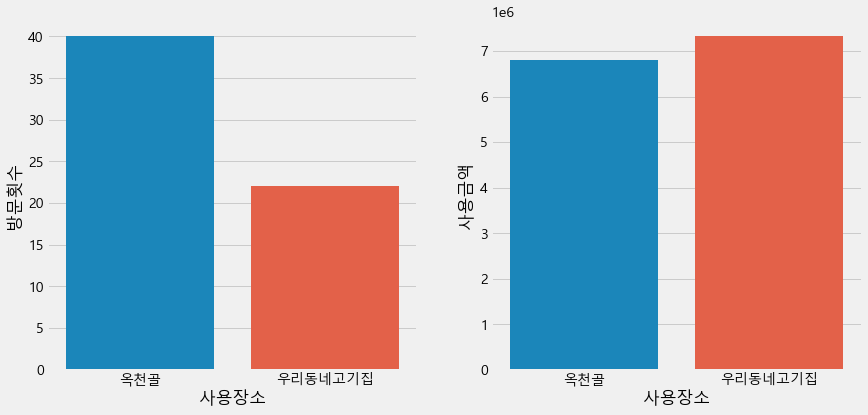

In [126]:
fig, axes = plt.subplots(ncols=2, figsize=(13, 6))
sns.barplot("사용장소", "방문횟수", data=df.iloc[[67, 72]], ax=axes[0])
sns.barplot("사용장소", "사용금액", data=df.iloc[[67, 72]], ax=axes[1])
plt.show()

## 지도 시각화해보기

### 데이터 불러오기

In [47]:
df = pd.read_csv('./dataset/업무추진비_지도.csv')
df

,사용장소,방문횟수,사용금액,카테고리,주소,lat,lng
0,가마솥,4,224000,보양식,서울 관악구 관악로17길 13 가마솥,37.480721,126.951002
1,감나무집,33,6527500,한식,서울 관악구 관악로11길 20 감나무집,37.477906,126.951002
2,강강술래,21,5068500,고기,서울 관악구 남부순환로 1660 강강술래,37.484604,126.935058
3,강촌민물매운탕2호점,7,547000,해물,서울 동작구 보라매로5길 15 강촌민물매운탕2호점,37.498098,126.920755
4,갯바위,6,458000,해물,서울 관악구 남부순환로216길 13 갯바위,37.480840,126.949110
...,...,...,...,...,...,...,...
114,해물나라,17,1892000,해물,서울 관악구 남부순환로 1674 해물나라,37.469685,126.933227
115,홍콩반점,7,278500,중식,서울 관악구 관악로 152 홍콩반점,37.478742,126.952557
116,황복,6,390000,보양식,서울 관악구 봉천로 356 황복,37.483903,126.939363
117,후포리,4,535000,해물,서울 관악구 봉천로 388 후포리,37.482873,126.943077


### 지도 그려보기

In [3]:
# 관악구청을 중심으로 객체 생성하기
m = folium.Map([37.478408041522954, 126.9514186693129], zoom_start=10)
m

In [4]:
# 지도에 마커로 음식점 표시하기
for i in df.index:
    sub_lat =  df.loc[i, 'lat']
    sub_lng = df.loc[i, 'lng']
    
    title = df.loc[i, '사용장소']
    
    folium.Marker([sub_lat, sub_lng], tooltip=title).add_to(m)

m.save('sample.html')
m

In [5]:
# 그린파크식당 확인
df[df['사용장소']=='그린파크식당']

,사용장소,방문횟수,사용금액,카테고리,주소,lat,lng
9,그린파크식당,5,1600000,한식,인천 옹진군 백령면 백령로297번길 16 그린파크식당,37.971058,124.715432


+ 그린파크 식당은 제외해주자

In [6]:
# 그린파크식당 제거
df.drop(9, axis=0, inplace=True)
df.index = range(len(df))
df

,사용장소,방문횟수,사용금액,카테고리,주소,lat,lng
0,가마솥,4,224000,보양식,서울 관악구 관악로17길 13 가마솥,37.480721,126.951002
1,감나무집,33,6527500,한식,서울 관악구 관악로11길 20 감나무집,37.477906,126.951002
2,강강술래,21,5068500,고기,서울 관악구 남부순환로 1660 강강술래,37.484604,126.935058
3,강촌민물매운탕2호점,7,547000,해물,서울 동작구 보라매로5길 15 강촌민물매운탕2호점,37.498098,126.920755
4,갯바위,6,458000,해물,서울 관악구 남부순환로216길 13 갯바위,37.480840,126.949110
...,...,...,...,...,...,...,...
113,해물나라,17,1892000,해물,서울 관악구 남부순환로 1674 해물나라,37.469685,126.933227
114,홍콩반점,7,278500,중식,서울 관악구 관악로 152 홍콩반점,37.478742,126.952557
115,황복,6,390000,보양식,서울 관악구 봉천로 356 황복,37.483903,126.939363
116,후포리,4,535000,해물,서울 관악구 봉천로 388 후포리,37.482873,126.943077


### 히트맵 그려보기

In [7]:
m = folium.Map(
    location = [36.5053542, 127.7043419],
    zoom_start = 8,
    tiles = 'Cartodb Positron'
#     tiles='stamentoner'
)

data = []

for i in df.index:
    
    sub_lat =  df.loc[i, 'lat']
    sub_lng = df.loc[i, 'lng']
    
    data.append([sub_lat, sub_lng])

# 관악구청 마커로 표시
folium.Marker([37.478408041522954, 126.9514186693129], tooltip='관악구청').add_to(m)
    

    
HeatMap(data).add_to(m)

m.save('heat.html')
m

In [50]:
df.head()

,사용장소,방문횟수,사용금액,카테고리,주소,lat,lng
0,가마솥,4,224000,보양식,서울 관악구 관악로17길 13 가마솥,37.480721,126.951002
1,감나무집,33,6527500,한식,서울 관악구 관악로11길 20 감나무집,37.477906,126.951002
2,강강술래,21,5068500,고기,서울 관악구 남부순환로 1660 강강술래,37.484604,126.935058
3,강촌민물매운탕2호점,7,547000,해물,서울 동작구 보라매로5길 15 강촌민물매운탕2호점,37.498098,126.920755
4,갯바위,6,458000,해물,서울 관악구 남부순환로216길 13 갯바위,37.480840,126.949110


In [127]:
fig = px.scatter_mapbox(df, lat='lat', lon='lng', zoom=13.5,
                        size='방문횟수', size_max=20, 
                        hover_name='사용장소', hover_data=['방문횟수', '사용금액'],
                        color='카테고리',
                        mapbox_style='carto-positron', width=1000, height=1000,
                        center={'lat': 37.478408041522954, 'lon': 126.9514186693129})
fig.show()

In [62]:
# plot(fig, filename='map_by_tax', auto_open=True)

'https://plotly.com/~mingkipark/14/'

## plotly

In [10]:
df = cf.datagen.lines()
df.head()

,ZHE.KJ,BPC.CC,XKF.XU,USK.JN,ZXB.SQ
2015-01-01,0.433784,-0.236278,-0.209713,0.692216,1.287844
2015-01-02,-1.897353,-1.604360,0.223388,1.417573,1.735745
2015-01-03,-2.965613,-1.999844,0.994339,1.987054,1.391814
2015-01-04,-3.636502,-2.260576,1.091045,2.496243,1.820021
2015-01-05,-4.399146,-3.692575,1.740653,2.133489,0.318450


In [11]:
df.iplot(kind='line')

In [12]:
df = pd.DataFrame(np.random.rand(10, 4), columns=['A', 'B', 'C', 'D'])
df.head()

,A,B,C,D
0,0.156002,0.213603,0.949720,0.468308
1,0.437522,0.382581,0.999681,0.636582
2,0.305115,0.042695,0.065002,0.482155
3,0.309660,0.265453,0.272458,0.365762
4,0.299941,0.892721,0.804084,0.154206


In [13]:
df.iplot(kind='bar')

In [14]:
df.iplot(kind='bar', barmode='stack')

In [15]:
df['A'].iplot(kind='bar')

In [16]:
df.iplot(kind='barh', barmode='stack')

In [17]:
df['A'].iplot(kind='barh')

In [18]:
df.iplot(kind='area')

In [19]:
df.iplot(kind='area', fill=True)

In [20]:
df.iplot(fill=True) # default kind = 'scatter'

In [21]:
iris = px.data.iris()
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species,species_id
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1


In [22]:
fig = px.scatter(iris, x='sepal_width', y='sepal_length')
fig.show()